# Analisando dados multivariadamente
Agora iremos analisar utilizando dados de colunas diferentes, que podem ou não estabelecer correlações úteis para análise das hipóteses documentadas nesse módulo.

In [1]:
import pandas as pd

from common.utils.DataLoaders import load_json_to_dict

#! Carregue a partir dos dados unificados do script anterior
dados = load_json_to_dict('churn_tratado.out', parent_path='./data/output/')

df_tratado = pd.DataFrame.from_dict(dados)
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   bool   
 4   Dependents        7043 non-null   bool   
 5   tenure            7043 non-null   int64  
 6   Contract          7043 non-null   object 
 7   PaperlessBilling  7043 non-null   bool   
 8   PaymentMethod     7043 non-null   object 
 9   MonthlyCharges    7043 non-null   float64
 10  TotalCharges      7043 non-null   float64
 11  Churn             7043 non-null   bool   
 12  PhoneService      7043 non-null   bool   
 13  MultipleLines     7043 non-null   object 
 14  InternetService   7043 non-null   object 
 15  OnlineSecurity    7043 non-null   object 
 16  OnlineBackup      7043 non-null   object 


### Análise de clientes que possuem múltiplos serviços (todos os 3, em alguma opção válida)

- 3° Base em foco: Clientes com múltiplos serviços (internet, telefone, TV a cabo) têm uma taxa de churn menor.

In [2]:
#* Querys: analisando registros com determinadas condições

#? Base: 3. - Clientes com múltiplos serviços (internet, telefone, TV a cabo) têm uma taxa de churn menor.
# Clientes filtrados que possuem os 3 serviços:
clientes_multiplos_servicos = df_tratado[
    (df_tratado.PhoneService == True) &
    (df_tratado.InternetService != 'No') &
    (df_tratado.StreamingTV == 'Yes')
]
# query nativa

registros_diferentes_servicos = clientes_multiplos_servicos[
    ['PhoneService', 'InternetService', 'StreamingTV', 'Churn']
]
registros_diferentes_servicos.value_counts()

PhoneService  InternetService  StreamingTV  Churn
True          Fiber optic      Yes          False    1063
                                            True      687
              DSL              Yes          False     609
                                            True       63
Name: count, dtype: int64

<Axes: title={'center': 'Gráfico de Barras do Churn de Clientes com Múltiplos Serviços'}, xlabel='Churn', ylabel='Porcentagem (%)'>

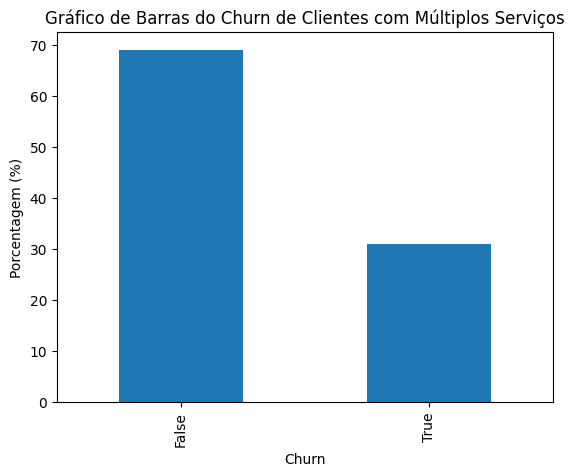

In [3]:
#* Mostrando dados

churn_multiplos_servicos = clientes_multiplos_servicos['Churn']

(churn_multiplos_servicos.value_counts(normalize=True) * 100).plot.bar(
    title='Gráfico de Barras do Churn de Clientes com Múltiplos Serviços',
    xlabel='Churn',
    ylabel='Porcentagem (%)'
)

#* Resultado: 30% dos clientes que possuem multiplos serviços (os 3 ao mesmo tempo) cancelaram contrato

#### Resultado 1:
 com esta análise, percebemos que uma grande porcentagem de clientes que cancelaram possuiam multiplos serviços contratados

<Axes: title={'center': 'Gráfico de Barras do Churn de Clientes sem Múltiplos Serviços'}, xlabel='Churn', ylabel='Porcentagem (%)'>

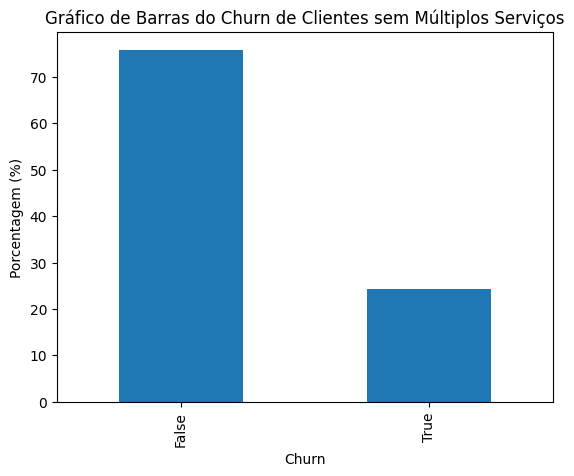

In [5]:
clientes_sem_multiplos_servicos = df_tratado[~(df_tratado.index.isin(clientes_multiplos_servicos.index))]

churn_sem_multiplos_servicos = clientes_sem_multiplos_servicos['Churn']
(churn_sem_multiplos_servicos.value_counts(normalize=True) * 100).plot.bar(
    title='Gráfico de Barras do Churn de Clientes sem Múltiplos Serviços',
    xlabel='Churn',
    ylabel='Porcentagem (%)'
)

#* Resultado do inverso: 25% dos clientes que não possuem multiplos serviços (os 3 ao mesmo tempo) cancelaram contrato

#### Resultado 2:
por fim, foi constatado que clientes que não tem nenhum dos serviços contratados não cancelaram contratos.

- Análise hipótese 3.: não há correlação entre cancelamentos e o fato dos clientes assinarem multiplos serviços ou não.

### Análise de clientes que possuem mais de 12 meses de contrato

- 4° Base em foco: Clientes com mais de 12 meses de contrato são mais propensos ao churn.

<Axes: title={'center': 'Gráfico de Barras do Churn de Clientes com Contrato Maior ou Igual a 12 Meses'}, xlabel='Churn', ylabel='Porcentagem (%)'>

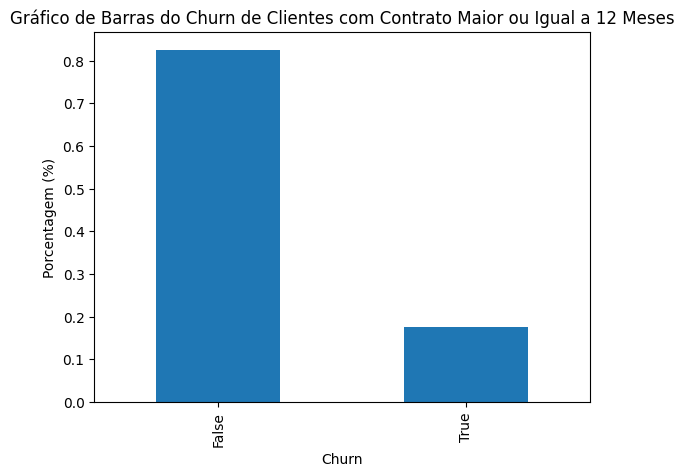

In [16]:

#? Base: 4. - Clientes com mais de 12 meses de contrato são mais propensos ao churn.
# Clientes filtrados que possuem mais de 12 meses de contrato:

df_clientes_contrato_maior_12_meses = df_tratado.query('tenure >= 12') #query interpretada
df_clientes_contrato_maior_12_meses.value_counts('Churn', normalize=True).plot.bar(
    title='Gráfico de Barras do Churn de Clientes com Contrato Maior ou Igual a 12 Meses',
    xlabel='Churn',
    ylabel='Porcentagem (%)'
)



<Axes: title={'center': 'Gráfico de Barras do Churn de Clientes com Contrato Menor que 12 Meses'}, xlabel='Churn', ylabel='Porcentagem (%)'>

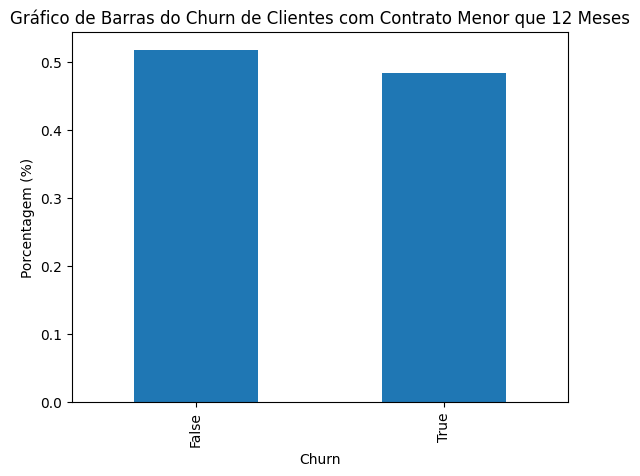

In [15]:

df_clientes_contrato_menor_12_meses = df_tratado.query('tenure < 12')
df_clientes_contrato_menor_12_meses.value_counts('Churn', normalize=True).plot.bar(
    title='Gráfico de Barras do Churn de Clientes com Contrato Menor que 12 Meses',
    xlabel='Churn',
    ylabel='Porcentagem (%)'
)

por fim, foi constatado que clientes que não tem nenhum dos serviços contratados não cancelaram contratos.

- Análise hipótese 3.: não há correlação entre cancelamentos e o fato dos clientes assinarem multiplos serviços ou não.